# FrotaIA — Classificação Inteligente do Estado de Conservação de Frota

Este notebook apresenta um **case anonimizado de portfólio** com aplicação de Machine Learning e IA Generativa para apoio à gestão da manutenção de frota.

O problema tratado é a necessidade de obter uma visão padronizada do estado de conservação de veículos distribuídos em diferentes localidades, a partir de inspeções simples feitas localmente por mecânicos.

A solução combina:

- testes de funcionamento de componentes codificados;
- regras de negócio associadas à segurança, criticidade e degradação acumulada;
- modelo Random Forest para classificação dos casos não definidos diretamente pelas regras;
- IA Generativa local para transformar a saída técnica em explicação gerencial.

Todos os dados foram anonimizados. Os veículos e componentes reais não são identificados.

## 1. Contexto do problema

Em uma frota distribuída geograficamente, a gestão da manutenção precisa acompanhar o estado dos veículos, planejar ações preventivas e corretivas, gerenciar estoque de peças e apoiar aquisições.

O desafio é obter esse panorama sem depender sempre do deslocamento de equipes especializadas. Para isso, mecânicos locais realizam inspeções rotineiras e informam se os componentes estão funcionando ou não. A gestão consolida essas informações em uma planilha, na qual os impactos das panes são ponderados com base em critérios técnicos definidos por especialistas.

A partir desses dados, o FrotaIA busca classificar a condição do veículo e gerar uma recomendação prática para apoiar a tomada de decisão.

## 2. Anonimização dos dados

A base utilizada neste case foi previamente anonimizada.

- Os veículos não são identificados por placa, número real ou localização.
- Os componentes avaliados foram codificados como `PEC1` até `PEC43`.
- A identificação original dos veículos foi substituída por códigos fictícios e removida da base usada na modelagem.
- O notebook trabalha apenas com resultados de testes codificados e classes de conservação.

Essa abordagem preserva a lógica metodológica do projeto sem expor informações operacionais sensíveis.

## Observação sobre a versão pública

Este notebook apresenta uma versão **anonimizada e demonstrativa** do projeto para fins de portfólio.

Por confidencialidade e proteção da lógica operacional, alguns elementos da solução foram omitidos ou simplificados, incluindo:

- agrupamentos técnicos completos de componentes;
- limiares específicos das regras de negócio;
- critérios operacionais detalhados de classificação;
- funções completas utilizadas na versão privada do classificador.

Os resultados agregados, métricas, gráficos e interpretações foram mantidos para demonstrar a abordagem metodológica, o raciocínio analítico e o valor gerencial da solução, sem expor critérios diretamente replicáveis.


In [ ]:
# ================================================================
# 1) INSTALAÇÃO DAS BIBLIOTECAS
# ================================================================

# No Google Colab, descomente a linha abaixo se necessário.
# !pip install pandas numpy scikit-learn openpyxl joblib matplotlib transformers sentencepiece torch -q

In [5]:
# ================================================================
# 2) IMPORTAÇÃO DAS BIBLIOTECAS
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score
)

try:
    from google.colab import files
    AMBIENTE_COLAB = True
except Exception:
    AMBIENTE_COLAB = False

pd.set_option("display.max_columns", 120)

## 3. Leitura e preparação da base anonimizada

A célula abaixo lê uma planilha anonimizada. Caso a base ainda contenha nomes originais de componentes, eles são substituídos por códigos genéricos `PEC1` a `PEC43`. O identificador do veículo é removido antes da modelagem.

A variável de saída esperada é a classe de conservação original, renomeada para `classif`.

In [6]:
# ================================================================
# 3) LEITURA DA BASE ANONIMIZADA
# ================================================================

if AMBIENTE_COLAB:
    print("Faça upload da base anonimizada em formato .xlsx ou .csv")
    uploaded = files.upload()
    nome_arquivo = list(uploaded.keys())[0]
else:
    # Ajuste o caminho abaixo caso esteja executando localmente.
    nome_arquivo = "base_frota_anonimizada.xlsx"

if nome_arquivo.lower().endswith((".xlsx", ".xls")):
    dados = pd.read_excel(nome_arquivo)
elif nome_arquivo.lower().endswith(".csv"):
    dados = pd.read_csv(nome_arquivo)
else:
    raise ValueError("Formato não suportado. Use .xlsx, .xls ou .csv")

print("Dimensão inicial da base:", dados.shape)
dados.head()

Faça upload da base anonimizada em formato .xlsx ou .csv


Saving base_frota_anonimizada_portfolio.xlsx to base_frota_anonimizada_portfolio.xlsx
Dimensão inicial da base: (220, 44)


,PEC1,PEC2,PEC3,PEC4,PEC5,PEC6,PEC7,PEC8,PEC9,PEC10,PEC11,PEC12,PEC13,PEC14,PEC15,PEC16,PEC17,PEC18,PEC19,PEC20,PEC21,PEC22,PEC23,PEC24,PEC25,PEC26,PEC27,PEC28,PEC29,PEC30,PEC31,PEC32,PEC33,PEC34,PEC35,PEC36,PEC37,PEC38,PEC39,PEC40,PEC41,PEC42,PEC43,classif
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,AM
1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,AM
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,AM
3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,AM
4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,AM


### Leitura da base

A base foi carregada em formato anonimizado, contendo apenas os componentes codificados e a classe de conservação de referência.

Cada linha representa um veículo avaliado, e cada coluna `PEC` representa um componente ou item de verificação. Como os nomes reais dos componentes foram removidos, o notebook preserva a confidencialidade dos dados originais e mantém apenas a estrutura necessária para a modelagem.

In [7]:
# ================================================================
# 4) PADRONIZAÇÃO E ANONIMIZAÇÃO OPERACIONAL
# ================================================================

# Caso a base ainda não esteja no formato PEC1..PEC43 + classif,
# aplica a anonimização estrutural utilizada no projeto.

colunas = list(dados.columns)

if "classif" not in dados.columns:
    novas_colunas = ["id_veic"] + [f"PEC{i}" for i in range(1, len(colunas))]
    dados.columns = novas_colunas

    # Na estrutura original anonimizada, a última PEC corresponde à classe.
    if "PEC44" in dados.columns:
        dados = dados.rename(columns={"PEC44": "classif"})

# Cria identificador fictício, se necessário, e remove da base de modelagem.
if "id_veic" not in dados.columns:
    dados.insert(0, "id_veic", [f"VEIC_DEMO_{str(i).zfill(3)}" for i in range(1, len(dados) + 1)])
else:
    dados["id_veic"] = [f"VEIC_DEMO_{str(i).zfill(3)}" for i in range(1, len(dados) + 1)]

base_dados = dados.drop(columns=["id_veic"]).copy()

# Garante tipo categórico para a classe.
base_dados["classif"] = base_dados["classif"].astype("category")

COLS_PEC = [f"PEC{i}" for i in range(1, 44)]

print("Dimensão da base de modelagem:", base_dados.shape)
print("Colunas de componentes:", len(COLS_PEC))
display(base_dados.head())

Dimensão da base de modelagem: (220, 44)
Colunas de componentes: 43


,PEC1,PEC2,PEC3,PEC4,PEC5,PEC6,PEC7,PEC8,PEC9,PEC10,PEC11,PEC12,PEC13,PEC14,PEC15,PEC16,PEC17,PEC18,PEC19,PEC20,PEC21,PEC22,PEC23,PEC24,PEC25,PEC26,PEC27,PEC28,PEC29,PEC30,PEC31,PEC32,PEC33,PEC34,PEC35,PEC36,PEC37,PEC38,PEC39,PEC40,PEC41,PEC42,PEC43,classif
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,AM
1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,AM
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,AM
3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,AM
4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,AM


### Preparação da base

Nesta etapa, a base é preparada para modelagem. Os componentes avaliados são padronizados no formato `PEC1` a `PEC43`, e a identificação individual dos veículos é removida.

Essa preparação garante que o modelo trabalhe apenas com informações técnicas dos testes e com a classe de conservação, sem expor dados sensíveis da frota.

## 4. Classes de conservação

A classificação utiliza cinco níveis operacionais:

| Classe | Interpretação gerencial |
|---|---|
| VD | Veículo livre para uso |
| AM | Veículo em uso com acompanhamento |
| AZ | Uso proibido até avaliação ou manutenção corretiva |
| LAR | Recuperação complexa ou necessidade de avaliação de custo-benefício |
| VM | Indicação preliminar de desfazimento ou recuperação excepcional |

,classe,quantidade,percentual
0,VD,13,5.9
1,AM,88,40.0
2,AZ,75,34.1
3,LAR,17,7.7
4,VM,27,12.3


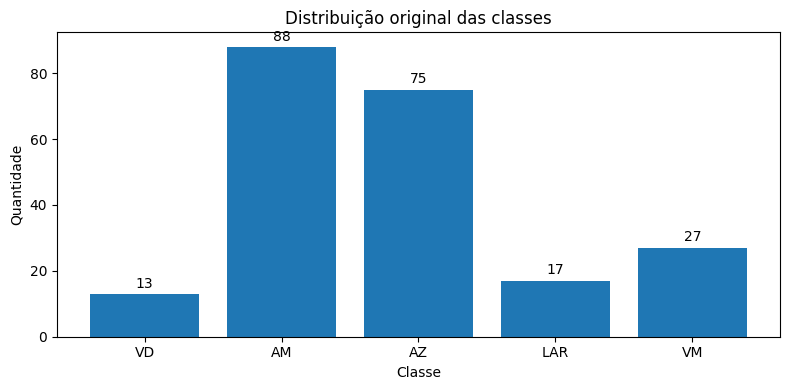

In [54]:
# ================================================================
# 5) DISTRIBUIÇÃO ORIGINAL DAS CLASSES
# ================================================================

# Ordem operacional das classes
ordem_classes = ["VD", "AM", "AZ", "LAR", "VM"]

class_dist = (
    base_dados["classif"]
    .value_counts()
    .reindex(ordem_classes, fill_value=0)
    .rename_axis("classe")
    .reset_index(name="quantidade")
)

class_dist["percentual"] = (
    100 * class_dist["quantidade"] / class_dist["quantidade"].sum()
).round(1)

display(class_dist)

plt.figure(figsize=(8, 4))
plt.bar(class_dist["classe"], class_dist["quantidade"])

plt.title("Distribuição original das classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

# Rótulos nas barras
for i, valor in enumerate(class_dist["quantidade"]):
    plt.text(
        i,
        valor + 1,
        str(valor),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Interpretação da distribuição original das classes

A distribuição original mostra que a base é composta majoritariamente por veículos em condições intermediárias de conservação.

As classes **AM** e **AZ** concentram a maior parte dos registros, com **88 veículos amarelos** e **75 veículos azuis**, representando juntas aproximadamente **74% da base**. Isso indica que a maior parte da frota avaliada não está em condição plenamente livre nem em situação extrema de desfazimento, mas sim em faixas que exigem acompanhamento, manutenção corretiva ou restrição de uso.

As classes mais críticas ou extremas aparecem com menor frequência. A classe **VM**, associada a possível desfazimento ou recuperação excepcional, representa **12,3%** da base. Já a classe **LAR**, relacionada a recuperação mais complexa, representa **7,7%**. A classe **VD**, que indica veículos livres para uso, aparece em apenas **5,9%** dos casos.

Do ponto de vista da modelagem, essa distribuição mostra um cenário desbalanceado. Algumas classes têm muitos exemplos, enquanto outras possuem poucos registros. Por isso, a avaliação do modelo não deve se basear apenas na acurácia geral. É necessário observar também o desempenho por classe, principalmente nas classes críticas, pois elas têm maior impacto para a gestão da manutenção.

Do ponto de vista gerencial, a distribuição reforça a importância de uma ferramenta de triagem: a frota apresenta predominância de veículos que exigem algum grau de atenção, seja por acompanhamento, manutenção corretiva, recuperação complexa ou avaliação para desfazimento.

## 5. Lógica da solução híbrida

O FrotaIA usa uma abordagem híbrida:

1. **Regras de negócio** identificam situações críticas relacionadas à segurança, recuperação complexa e degradação severa.
2. **Random Forest** classifica os casos não determinados diretamente pelas regras.
3. **IA Generativa local** transforma a saída técnica em explicação gerencial.

Essa estrutura evita depender apenas do modelo estatístico em situações de maior criticidade operacional.

In [22]:
# ================================================================
# 6) GRUPOS DE COMPONENTES USADOS NAS REGRAS — VERSÃO PÚBLICA
# ================================================================

# Na versão privada, os componentes codificados são organizados em grupos técnicos,
# como componentes associados à segurança e componentes de maior criticidade operacional.
#
# Esses agrupamentos completos foram omitidos nesta versão pública por conterem
# critérios técnicos específicos da solução.
#
# Para fins de portfólio, mantém-se a explicação metodológica e os resultados
# agregados, sem expor a composição exata dos grupos.


In [23]:
# ================================================================
# 7) REGRAS DE NEGÓCIO E INDICADORES DE IMPACTO — VERSÃO PÚBLICA
# ================================================================

# A versão privada do projeto calcula indicadores de impacto e aplica regras de negócio
# relacionadas a segurança, criticidade e degradação acumulada.
#
# Por confidencialidade, os limiares completos e os critérios operacionais detalhados
# foram omitidos nesta versão pública.
#
# A lógica geral é:
# 1. contar componentes afetados;
# 2. calcular impacto total e impactos por grupos técnicos;
# 3. identificar condições de segurança e criticidade;
# 4. classificar diretamente casos críticos por regra;
# 5. encaminhar os demais casos para o modelo de Machine Learning.
#
# Os resultados apresentados nas próximas células foram gerados pela versão completa
# do classificador e preservados neste notebook para fins demonstrativos.


In [24]:
# ================================================================
# 8) APLICAÇÃO DAS REGRAS E CRIAÇÃO DO ALVO HÍBRIDO — RESULTADO DEMONSTRATIVO
# ================================================================

# As tabelas abaixo foram geradas pela versão privada das regras de negócio.
# A lógica completa foi omitida nesta versão pública para preservar os critérios técnicos.
#
# O objetivo desta célula é apresentar o efeito das regras na construção do alvo híbrido,
# sem expor os agrupamentos e limiares utilizados na solução operacional.


1) Comparação entre classificação original e resultado das regras:


Resultado da regra,AZ,LAR,ML,VM,All
Classificação original,,,,,
AM,26,13,45,4,88
AZ,24,14,35,2,75
LAR,4,2,9,2,17
VD,5,0,8,0,13
VM,1,0,8,18,27
All,60,29,105,26,220


2) Comparação entre classificação original e alvo híbrido:


Alvo híbrido,AM,AZ,LAR,VD,VM,All
Classificação original,,,,,,
AM,45,26,13,0,4,88
AZ,0,59,14,0,2,75
LAR,0,4,11,0,2,17
VD,0,5,0,8,0,13
VM,0,1,0,0,26,27
All,45,95,38,8,34,220


3) Distribuição final do alvo híbrido:


,Classe do alvo híbrido,Quantidade,Percentual
0,AM,45,20.5
1,AZ,95,43.2
2,LAR,38,17.3
3,VD,8,3.6
4,VM,34,15.5


### Interpretação da criação do alvo híbrido

Esta etapa mostra como a classificação original foi ajustada pelas regras de negócio para formar o alvo híbrido usado na modelagem.

A primeira tabela compara a **classificação original** com o **resultado das regras de negócio**. Quando a regra retorna `ML`, significa que ela não identificou uma condição crítica suficiente para alterar diretamente a classe do veículo. Nesses casos, a decisão fica para o modelo de Machine Learning.

Na base analisada, as regras classificaram diretamente:

- **60 veículos como AZ**, por critérios associados à segurança ou necessidade de manutenção corretiva;
- **29 veículos como LAR**, por indícios de recuperação mais complexa ou presença de componente crítico;
- **26 veículos como VM**, por sinais de degradação severa;
- **105 veículos como ML**, ou seja, casos sem enquadramento direto pelas regras.

A segunda tabela mostra como ficou o **alvo híbrido**. Ele é construído da seguinte forma:

- quando a regra define uma classe crítica, essa classe é mantida no alvo;
- quando a regra retorna `ML`, a classificação original é preservada.

Por isso, o alvo híbrido não é igual à classificação original nem igual apenas à regra. Ele combina as duas informações: a classificação registrada na base e os critérios operacionais definidos pelas regras de negócio.

A distribuição final do alvo híbrido mostra uma mudança importante no perfil da base. A classe **AZ** passou a concentrar **95 veículos**, ou **43,2%** do total, tornando-se a classe mais frequente. Isso reflete a lógica operacional adotada: quando há sinal de comprometimento de segurança ou necessidade de manutenção corretiva, o sistema tende a restringir o uso do veículo.

As classes **LAR** e **VM** também aumentaram em relação à distribuição original, passando para **38 veículos** e **34 veículos**, respectivamente. Isso indica que as regras trouxeram para classes mais restritivas alguns casos que, pela lógica operacional, merecem maior atenção da gestão.

Já as classes **AM** e **VD** ficaram menores no alvo híbrido. A classe **VD**, por exemplo, passou para apenas **8 veículos**, reforçando que a condição de veículo livre para uso foi tratada de forma mais conservadora.

Em termos práticos, o alvo híbrido torna o treinamento mais alinhado à gestão da manutenção. O modelo passa a aprender uma classificação que não apenas reproduz o histórico, mas incorpora critérios de segurança, criticidade e degradação relevantes para decisões de uso, manutenção, recuperação e possível desfazimento.

In [25]:
# ================================================================
# 9) PERFIL DE IMPACTO POR CLASSE — RESULTADO DEMONSTRATIVO
# ================================================================

# O resumo abaixo foi gerado a partir dos indicadores da versão completa do classificador.
# Os critérios operacionais detalhados foram omitidos, mas os resultados agregados
# foram mantidos para demonstrar a coerência do perfil de impacto por classe.


,qtd_veiculos,media_qtd_componentes,mediana_qtd_componentes,media_impacto_total,mediana_impacto_total,media_impacto_seguranca,media_impacto_especiais
classif,,,,,,,
AM,88,2.50,2.0,4.80,4.5,2.07,1.08
AZ,75,2.40,2.0,4.55,5.0,2.13,0.73
LAR,17,2.29,1.0,4.71,4.0,2.35,0.94
VD,13,0.92,1.0,2.23,1.0,1.54,0.00
VM,27,11.30,6.0,25.93,9.0,7.56,7.93


### Interpretação do perfil de impacto por classe

O perfil de impacto mostra uma diferença clara entre a classe **VM** e as demais classes.

Os veículos classificados como **VM** apresentam, em média, **11,3 componentes afetados**, contra valores próximos de **2 componentes** nas classes AM, AZ e LAR. Além disso, o impacto total médio da classe VM é de **25,93**, muito superior ao observado nas demais classes, que ficam próximas de **4 a 5 pontos**.

Esse resultado indica que a classe VM não está associada apenas à existência de uma pane isolada. Ela representa um padrão de **degradação mais ampla e acumulada**, com maior quantidade de componentes afetados e maior impacto operacional.

As classes **AM**, **AZ** e **LAR** apresentam médias de impacto total relativamente próximas. Isso sugere que a separação entre essas classes não depende apenas da quantidade de componentes afetados ou do impacto total, mas também da natureza dos componentes envolvidos, especialmente aqueles relacionados à segurança, criticidade e complexidade de recuperação.

A classe **VD** apresenta o menor nível de impacto, com média de **0,92 componente afetado** e impacto total médio de **2,23**. Esse comportamento é coerente com a interpretação de veículos em melhor condição operacional.

Do ponto de vista gerencial, essa análise reforça a utilidade das regras de negócio. A quantidade de panes ajuda a identificar degradação geral, mas o peso operacional dos componentes é essencial para diferenciar veículos que podem continuar em uso, veículos que exigem manutenção corretiva, casos de recuperação complexa e situações com possível indicação de desfazimento.

## 6. Modelagem com Random Forest

O modelo Random Forest foi escolhido por sua capacidade de lidar com relações não lineares entre os componentes avaliados e a classe final, além de permitir interpretação aproximada da importância das variáveis.

In [26]:
# ================================================================
# 10) SEPARAÇÃO TREINO/TESTE
# ================================================================

X = base_dados[COLS_PEC].copy()
y = base_dados["y_hibrido"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Dimensão do treino:", X_train.shape)
print("Dimensão do teste:", X_test.shape)

display(pd.DataFrame({
    "treino": y_train.value_counts().sort_index(),
    "teste": y_test.value_counts().sort_index()
}).fillna(0).astype(int))

Dimensão do treino: (154, 43)
Dimensão do teste: (66, 43)


,treino,teste
y_hibrido,,
AM,31,14
AZ,66,29
LAR,27,11
VD,6,2
VM,24,10


In [27]:
# ================================================================
# 11) TREINAMENTO DO MODELO
# ================================================================

modelo_hibrido = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=6,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

modelo_hibrido.fit(X_train, y_train)

print("Modelo treinado com sucesso.")

Modelo treinado com sucesso.


In [28]:
# ================================================================
# 12) PREDIÇÃO FINAL COM REGRAS DE NEGÓCIO — VERSÃO PÚBLICA
# ================================================================

# Na versão privada, a predição final combina a saída do modelo Random Forest
# com regras de negócio que podem sobrescrever a classe prevista quando há condição crítica.
#
# A função operacional completa foi omitida nesta versão pública para preservar
# os critérios técnicos de classificação.
#
# Os resultados de avaliação apresentados a seguir foram preservados como evidência
# do desempenho da abordagem híbrida.


,count
AM,15
AZ,24
LAR,8
VD,9
VM,10


In [29]:
# ================================================================
# 13) AVALIAÇÃO DO MODELO
# ================================================================

classes_ordem = ["VD", "AM", "AZ", "LAR", "VM"]

matriz_confusao = confusion_matrix(y_test, y_pred_final, labels=classes_ordem)
matriz_confusao_df = pd.DataFrame(
    matriz_confusao,
    index=[f"Real_{classe}" for classe in classes_ordem],
    columns=[f"Pred_{classe}" for classe in classes_ordem]
)

display(matriz_confusao_df)

print(classification_report(
    y_test,
    y_pred_final,
    labels=classes_ordem,
    zero_division=0
))

,Pred_VD,Pred_AM,Pred_AZ,Pred_LAR,Pred_VM
Real_VD,2,0,0,0,0
Real_AM,3,11,0,0,0
Real_AZ,3,2,24,0,0
Real_LAR,1,2,0,8,0
Real_VM,0,0,0,0,10


              precision    recall  f1-score   support

          VD       0.22      1.00      0.36         2
          AM       0.73      0.79      0.76        14
          AZ       1.00      0.83      0.91        29
         LAR       1.00      0.73      0.84        11
          VM       1.00      1.00      1.00        10

    accuracy                           0.83        66
   macro avg       0.79      0.87      0.77        66
weighted avg       0.92      0.83      0.86        66



### Interpretação da avaliação do modelo

O modelo híbrido apresentou desempenho geral satisfatório no conjunto de teste:

- **Acurácia:** 83%;
- **F1 ponderado:** 0,86;
- melhor desempenho nas classes críticas, especialmente **VM**, **AZ** e **LAR**.

#### Pontos fortes

- A classe **VM** foi totalmente identificada no teste, com **10 acertos em 10 casos**.
- A classe **AZ** teve bom desempenho: **24 dos 29 veículos AZ** foram classificados corretamente.
- A classe **LAR** também apresentou boa precisão: quando o modelo classificou como LAR, a classificação foi correta.

Esses resultados são relevantes porque as classes **AZ**, **LAR** e **VM** concentram decisões mais sensíveis para a gestão da manutenção, como restrição de uso, recuperação complexa ou possível desfazimento.

#### Ponto de atenção

A principal fragilidade está na classe **VD**. Embora os **2 veículos VD reais** tenham sido corretamente identificados, outros veículos das classes **AM**, **AZ** e **LAR** também foram classificados como VD.

Esse é o erro operacionalmente mais sensível, pois pode indicar liberação indevida de veículos que deveriam ter acompanhamento, restrição ou avaliação mais cuidadosa.

Por isso, a próxima etapa do notebook analisa especificamente os **falsos verdes**, verificando se esses casos apresentavam sinais relevantes de pane ou se a divergência pode estar associada a informações não disponíveis na base.

In [30]:
# ================================================================
# 14) COMPARAÇÃO TREINO/TESTE
# ================================================================

y_pred_train = predizer_com_regras(modelo_hibrido, X_train)
y_pred_test = predizer_com_regras(modelo_hibrido, X_test)

comparacao_overfitting = pd.DataFrame({
    "Métrica": ["Acurácia", "F1 macro", "F1 ponderado"],
    "Treino": [
        accuracy_score(y_train, y_pred_train),
        f1_score(y_train, y_pred_train, average="macro"),
        f1_score(y_train, y_pred_train, average="weighted")
    ],
    "Teste": [
        accuracy_score(y_test, y_pred_test),
        f1_score(y_test, y_pred_test, average="macro"),
        f1_score(y_test, y_pred_test, average="weighted")
    ]
})

comparacao_overfitting["Diferença treino - teste"] = comparacao_overfitting["Treino"] - comparacao_overfitting["Teste"]

display(comparacao_overfitting.round(3))

,Métrica,Treino,Teste,Diferença treino - teste
0,Acurácia,0.825,0.833,-0.009
1,F1 macro,0.782,0.774,0.008
2,F1 ponderado,0.843,0.862,-0.019


### Verificação de sobreajuste

A comparação entre treino e teste não indica evidência relevante de overfitting.

As métricas ficaram muito próximas nos dois conjuntos. A acurácia foi de **0,825 no treino** e **0,833 no teste**, enquanto o F1 ponderado foi de **0,843 no treino** e **0,862 no teste**.

Como o desempenho no teste não caiu em relação ao treino, o modelo não parece ter apenas memorizado os dados de treinamento. Esse resultado reforça que a solução apresenta comportamento consistente para um MVP, embora a validação cruzada ainda seja necessária para avaliar melhor a estabilidade em diferentes divisões da base.

In [56]:
# ================================================================
# 15) VALIDAÇÃO CRUZADA ESTRATIFICADA
# ================================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados_cv = []

for i, (idx_treino, idx_teste) in enumerate(skf.split(X, y), start=1):
    X_treino_cv = X.iloc[idx_treino]
    X_teste_cv = X.iloc[idx_teste]
    y_treino_cv = y.iloc[idx_treino]
    y_teste_cv = y.iloc[idx_teste]

    modelo_cv = RandomForestClassifier(
        n_estimators=500,
        max_depth=12,
        min_samples_split=6,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42
    )

    modelo_cv.fit(X_treino_cv, y_treino_cv)
    y_pred_cv = predizer_com_regras(modelo_cv, X_teste_cv)

    resultados_cv.append({
        "fold": i,
        "accuracy": accuracy_score(y_teste_cv, y_pred_cv),
        "f1_macro": f1_score(y_teste_cv, y_pred_cv, average="macro"),
        "f1_weighted": f1_score(y_teste_cv, y_pred_cv, average="weighted")
    })

resultados_cv = pd.DataFrame(resultados_cv)
resumo_cv = (
    resultados_cv[["accuracy", "f1_macro", "f1_weighted"]]
    .agg(["mean", "std"])
    .round(3)
)

display(resumo_cv)

#display(resultados_cv.round(3))


,accuracy,f1_macro,f1_weighted
mean,0.786,0.733,0.811
std,0.061,0.059,0.048


### Interpretação da validação cruzada

A validação cruzada mostra que o desempenho do modelo se mantém em patamar satisfatório quando a base é dividida de diferentes formas.

A acurácia média foi de **0,786**, com F1 ponderado médio de **0,811**. Esses valores são um pouco menores do que os obtidos na divisão treino/teste, mas representam uma estimativa mais realista da capacidade de generalização do modelo.

Houve variação entre os folds, com acurácia entre **0,705** e **0,864**. Essa oscilação é esperada, pois a base é pequena e possui classes desbalanceadas. Nesses casos, a composição de cada divisão pode afetar o desempenho.

Mesmo com essa variação, os resultados indicam que a abordagem híbrida apresenta estabilidade suficiente para um MVP. A solução não deve ser interpretada como modelo definitivo, mas como uma ferramenta promissora de triagem e apoio à decisão na gestão da manutenção.

In [32]:
# ================================================================
# 16) ANÁLISE DE ERROS OPERACIONAIS — RESULTADO DEMONSTRATIVO
# ================================================================

# A análise abaixo foi gerada a partir da versão completa do classificador híbrido.
# Foram preservados os resultados agregados necessários para interpretar os erros
# operacionais, sem expor a lógica completa de regras e limiares.


,Indicador,Resultado
0,Quantidade de falsos verdes,7
1,Quantidade de falsos agravamentos,0


,classe_real,classe_predita,qtd_componentes_afetados,impacto_total,impacto_pec_seguranca,impacto_pec_especiais,condicao_seguranca,condicao_peca_critica
118,AZ,VD,0,0,0,0,False,False
151,AZ,VD,0,0,0,0,False,False
172,LAR,VD,1,1,0,0,False,False
115,AZ,VD,0,0,0,0,False,False
2,AM,VD,0,0,0,0,False,False
36,AM,VD,2,2,0,0,False,False
43,AM,VD,0,0,0,0,False,False


### Interpretação dos erros operacionais

O modelo apresentou **7 falsos verdes** e **0 falsos agravamentos**.

#### Falsos verdes

Os falsos verdes são os casos em que o sistema classificou como **VD**, embora a referência fosse mais restritiva.

Apesar de esse ser o erro mais sensível operacionalmente, os casos encontrados apresentaram baixo risco nos dados disponíveis:

- 5 de 7 veículos não tinham componentes afetados;
- nenhum caso apresentou impacto em segurança;
- nenhum caso apresentou impacto em componentes especiais;
- nenhuma regra crítica foi acionada.

Isso indica que, com as informações registradas nos testes, esses veículos tinham perfil compatível com uma classificação menos restritiva.

#### Falsos agravamentos

Não houve falsos agravamentos.

Isso significa que o sistema não elevou indevidamente veículos leves para classes críticas, evitando restrições excessivas sem evidência registrada.

#### Leitura gerencial

As divergências observadas parecem estar mais ligadas à ausência de informações complementares na base, como histórico de manutenção, avaliação visual ou disponibilidade de peças, do que a um comportamento inadequado do modelo.

In [33]:
# ================================================================
# 17) SÍNTESE DOS RESULTADOS
# ================================================================

sintese_modelo = pd.DataFrame({
    "Indicador": [
        "Acurácia no teste",
        "F1 macro no teste",
        "F1 ponderado no teste",
        "Acurácia média na validação cruzada",
        "F1 macro médio na validação cruzada",
        "F1 ponderado médio na validação cruzada",
        "Quantidade de falsos verdes",
        "Quantidade de falsos agravamentos"
    ],
    "Resultado": [
        round(accuracy_score(y_test, y_pred_final), 3),
        round(f1_score(y_test, y_pred_final, average="macro"), 3),
        round(f1_score(y_test, y_pred_final, average="weighted"), 3),
        round(resultados_cv["accuracy"].mean(), 3),
        round(resultados_cv["f1_macro"].mean(), 3),
        round(resultados_cv["f1_weighted"].mean(), 3),
        len(falsos_verdes),
        len(falsos_agravamentos)
    ]
})

display(sintese_modelo)

,Indicador,Resultado
0,Acurácia no teste,0.833
1,F1 macro no teste,0.774
2,F1 ponderado no teste,0.862
3,Acurácia média na validação cruzada,0.786
4,F1 macro médio na validação cruzada,0.733
5,F1 ponderado médio na validação cruzada,0.811
6,Quantidade de falsos verdes,7.000
7,Quantidade de falsos agravamentos,0.000


### Síntese dos resultados

A síntese confirma que o modelo híbrido apresentou desempenho satisfatório para um MVP.

#### Desempenho geral

No conjunto de teste, o sistema alcançou:

- **83,3% de acurácia**;
- **F1 ponderado de 0,862**;
- **F1 macro de 0,774**.

Esses resultados indicam boa capacidade geral de classificação, especialmente considerando o tamanho reduzido da base e o desbalanceamento entre as classes.

#### Estabilidade do modelo

Na validação cruzada, o desempenho médio ficou em:

- **78,6% de acurácia**;
- **F1 ponderado de 0,811**;
- **F1 macro de 0,733**.

Esses valores são um pouco menores do que os obtidos no teste, mas oferecem uma estimativa mais realista da capacidade de generalização do modelo.

#### Leitura operacional

A análise dos erros mostrou **7 falsos verdes** e **nenhum falso agravamento**.

Isso indica que o principal ponto de atenção está em alguns veículos classificados como livres para uso, embora tivessem referência mais restritiva. No entanto, esses casos apresentaram baixo ou nenhum sinal de pane nos dados disponíveis.

Por outro lado, a ausência de falsos agravamentos mostra que o sistema não elevou indevidamente veículos leves para classes críticas.

De forma geral, os resultados indicam que o FrotaIA é promissor como ferramenta de triagem e apoio à decisão para gestão da manutenção.

## 7. Importância das variáveis

A importância das variáveis permite verificar quais componentes codificados mais contribuíram para a classificação do modelo. Como os dados estão anonimizados, os componentes permanecem identificados apenas como `PEC`.

,PEC,importancia
16,PEC17,0.153069
3,PEC4,0.145886
2,PEC3,0.144633
15,PEC16,0.110576
0,PEC1,0.085067
1,PEC2,0.082096
4,PEC5,0.073721
37,PEC38,0.021234
8,PEC9,0.020436
13,PEC14,0.018350


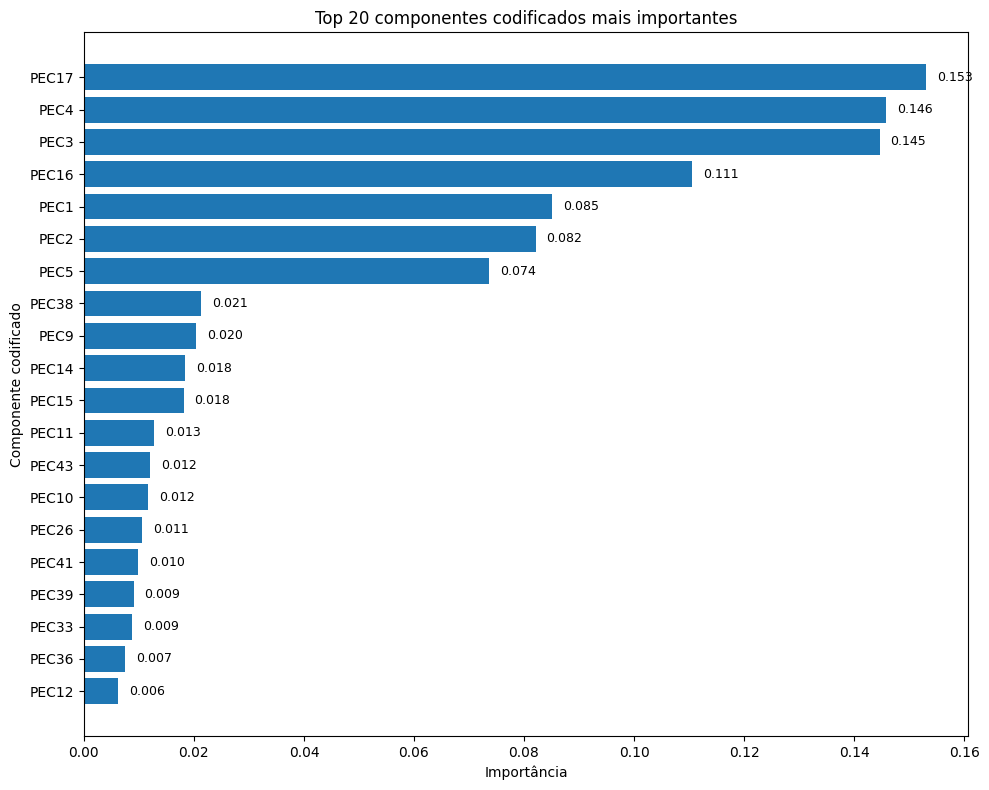

In [34]:
# ================================================================
# 18) IMPORTÂNCIA DAS PECs
# ================================================================

importancias = pd.DataFrame({
    "PEC": X_train.columns,
    "importancia": modelo_hibrido.feature_importances_
}).sort_values("importancia", ascending=False)

display(importancias.head(20))

top20_importancias = importancias.head(20).sort_values("importancia")

plt.figure(figsize=(10, 8))
plt.barh(top20_importancias["PEC"], top20_importancias["importancia"])

for i, v in enumerate(top20_importancias["importancia"]):
    plt.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)

plt.title("Top 20 componentes codificados mais importantes")
plt.xlabel("Importância")
plt.ylabel("Componente codificado")
plt.tight_layout()
plt.show()

### Leitura da importância das PECs

O modelo concentrou parte relevante da decisão em um conjunto reduzido de componentes codificados.

#### Principais PECs

As maiores importâncias apareceram em:

- **PEC17**;
- **PEC4**;
- **PEC3**;
- **PEC16**;
- **PEC1**;
- **PEC2**.

Isso indica que esses componentes tiveram maior peso para diferenciar os estados de conservação dos veículos.

#### Uso gerencial

Na prática, essa informação pode apoiar o planejamento da manutenção e da aquisição de peças.

Componentes com maior importância no modelo tendem a ter maior impacto na classificação do estado da frota. Assim, conhecer essas PECs ajuda a:

- priorizar aquisição de peças mais relevantes para melhorar os índices de conservação;
- orientar a composição de estoque mínimo;
- apoiar decisões em cenário de restrição orçamentária;
- direcionar a atenção para componentes que mais influenciam a condição operacional dos veículos;
- subsidiar planejamento de manutenção preventiva e corretiva.

#### Cuidado na interpretação

A importância de uma PEC não significa que ela, isoladamente, determine a classificação final. O modelo considera o conjunto dos componentes avaliados, e a decisão final também incorpora regras de negócio relacionadas à segurança, criticidade e degradação acumulada.

Mesmo assim, a análise de importância é útil para identificar quais itens possuem maior valor informativo e podem receber prioridade em futuras revisões do processo de inspeção, planejamento de compras e gestão de estoque.

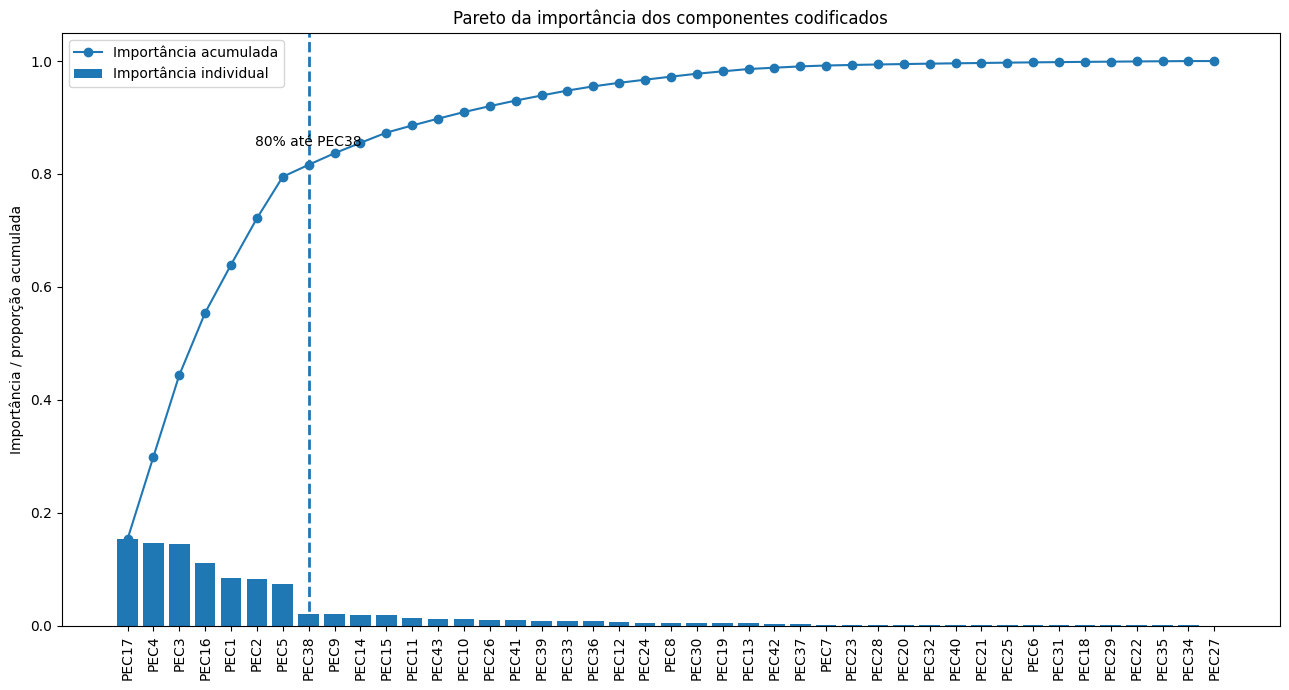

O ponto de corte de 80% ocorre em PEC38, com acumulado de 81.6%.


In [35]:
# ================================================================
# 19) GRÁFICO DE PARETO DAS IMPORTÂNCIAS
# ================================================================

df_pareto = importancias.sort_values("importancia", ascending=False).reset_index(drop=True)
df_pareto["acumulada"] = df_pareto["importancia"].cumsum()
df_pareto["acumulada_pct"] = 100 * df_pareto["acumulada"] / df_pareto["importancia"].sum()

cutoff_idx = df_pareto[df_pareto["acumulada_pct"] >= 80].index[0]
cutoff_pec = df_pareto.loc[cutoff_idx, "PEC"]
cutoff_pct = df_pareto.loc[cutoff_idx, "acumulada_pct"]

plt.figure(figsize=(13, 7))
plt.bar(df_pareto["PEC"], df_pareto["importancia"], label="Importância individual")
plt.plot(df_pareto["PEC"], df_pareto["acumulada_pct"] / 100, marker="o", label="Importância acumulada")
plt.axvline(x=cutoff_idx, linestyle="--", linewidth=2)
plt.text(cutoff_idx, 0.85, f"80% até {cutoff_pec}", ha="center", fontsize=10)
plt.xticks(rotation=90)
plt.ylabel("Importância / proporção acumulada")
plt.title("Pareto da importância dos componentes codificados")
plt.legend()
plt.tight_layout()
plt.show()

print(f"O ponto de corte de 80% ocorre em {cutoff_pec}, com acumulado de {cutoff_pct:.1f}%.")

### Leitura do Pareto das importâncias

O gráfico de Pareto mostra que a importância do modelo está concentrada em um conjunto relativamente pequeno de componentes codificados.

O ponto de corte de **80% da importância acumulada** ocorre até a **PEC38**, com aproximadamente **81,6%** da importância total. Isso significa que uma parte reduzida das PECs concentra a maior capacidade explicativa do modelo para diferenciar os estados de conservação dos veículos.

#### Leitura gerencial

Na prática, esse resultado ajuda a transformar a modelagem em apoio ao planejamento logístico.

As PECs que aparecem antes do ponto de corte de 80% representam os componentes com maior peso informativo para a classificação da frota. Portanto, elas podem subsidiar decisões como:

- priorização de aquisição de peças;
- definição de estoque mínimo;
- planejamento em cenário de restrição orçamentária;
- foco em componentes que mais influenciam a condição operacional dos veículos;
- revisão de rotinas de inspeção e manutenção preventiva.

#### Cuidado na interpretação

O Pareto não significa que os demais componentes devam ser ignorados. A classificação do veículo continua dependendo do conjunto de testes e das regras de negócio.

No entanto, o resultado indica que, se houver limitação de recursos, os componentes mais importantes para o modelo podem receber atenção prioritária, pois tendem a contribuir mais para a melhoria dos índices de conservação da frota.

## 8. Função operacional para classificar novos veículos

A função abaixo transforma o modelo em uma rotina de uso prático. Ela recebe uma nova linha com `PEC1` a `PEC43`, aplica o modelo, reaplica as regras de negócio e retorna a classe final, a origem da decisão e indicadores de apoio à gestão.

In [36]:
# ================================================================
# 20) FUNÇÃO FINAL PARA CLASSIFICAR NOVOS VEÍCULOS — VERSÃO PÚBLICA
# ================================================================

# Na versão privada, esta etapa implementa a função operacional completa para
# classificar novos veículos a partir dos testes de componentes.
#
# Por confidencialidade, a implementação completa não é disponibilizada neste
# repositório público.
#
# A interface conceitual da função seria:
#
# def classificar_nova_frota(modelo, df_nova_frota):
#     Recebe os testes codificados de componentes e retorna:
#     - classe sugerida pelo modelo;
#     - classe final após regras de negócio;
#     - origem da decisão;
#     - indicadores gerenciais;
#     - recomendação associada.
#
# O exemplo fictício da próxima célula reproduz a saída esperada da função,
# sem expor a lógica operacional completa.


In [57]:
# ================================================================
# TEXTOS PADRÃO POR CLASSE
# ================================================================

TEXTOS_CLASSE = {
    "VD": {
        "nome": "Verde",
        "situacao": "O veículo está liberado para uso.",
        "motivo": "Os testes informados não indicam pane relevante.",
        "acao": "Manter em operação e seguir o acompanhamento normal da manutenção.",
        "recomendacao": "Livre para uso."
    },
    "AM": {
        "nome": "Amarela",
        "situacao": "O veículo pode permanecer em uso, mas requer acompanhamento.",
        "motivo": "Há sinais de conservação reduzida, sem indicação imediata de restrição crítica.",
        "acao": "Programar manutenção conforme disponibilidade e acompanhar a evolução das panes.",
        "recomendacao": "Manter em uso com acompanhamento."
    },
    "AZ": {
        "nome": "Azul",
        "situacao": "O veículo não deve ser utilizado até passar por avaliação técnica ou manutenção corretiva.",
        "motivo": "Os testes indicaram possível comprometimento de segurança.",
        "acao": "Restringir o uso do veículo e priorizar a manutenção corretiva.",
        "recomendacao": "Uso proibido até manutenção corretiva ou avaliação técnica."
    },
    "LAR": {
        "nome": "Laranja",
        "situacao": "O veículo apresenta estado de degradação avançado e exige avaliação criteriosa sobre a viabilidade de recuperação.",
        "motivo": "Há indício de recuperação complexa, maior custo ou presença de componente crítico.",
        "acao": "Avaliar custo-benefício da recuperação e verificar disponibilidade de peças.",
        "recomendacao": "Avaliar recuperação complexa e possível uso como fonte de peças."
    },
    "VM": {
        "nome": "Vermelha",
        "situacao": "O veículo apresenta indicação preliminar de desfazimento ou recuperação excepcional.",
        "motivo": "O conjunto de testes indica degradação severa, com recuperação possivelmente não compensatória.",
        "acao": "Encaminhar para parecer técnico e avaliação patrimonial antes da decisão final.",
        "recomendacao": "Avaliar desfazimento ou recuperação excepcional mediante parecer técnico."
    }
}


def gerar_recomendacao_gerencial(classe: str) -> str:
    return TEXTOS_CLASSE.get(
        classe,
        {"recomendacao": "Classe não reconhecida. Verificar cadastro."}
    )["recomendacao"]


In [46]:
# ================================================================
# 21) EXEMPLO FICTÍCIO DE CLASSIFICAÇÃO
# ================================================================

# Exemplo demonstrativo de saída da função operacional.
# A entrada detalhada e a lógica completa de classificação foram omitidas
# por confidencialidade nesta versão pública.

saida_gestao = pd.DataFrame([
    {
        "classe_modelo": "VD",
        "classe_final": "AZ",
        "nome_classe": TEXTOS_CLASSE["AZ"]["nome"],
        "origem_decisao": "Regra de segurança",
        "qtd_componentes_afetados": 2,
        "impacto_total": 5,
        "impacto_pec_seguranca": 5,
        "impacto_pec_especiais": 0,
        "condicao_seguranca": True,
        "condicao_peca_critica": False,
        "recomendacao_gerencial": gerar_recomendacao_gerencial("AZ")
    }
])

display(saida_gestao)


,classe_modelo,classe_final,nome_classe,origem_decisao,qtd_componentes_afetados,impacto_total,impacto_pec_seguranca,impacto_pec_especiais,condicao_seguranca,condicao_peca_critica,recomendacao_gerencial
0,VD,AZ,Azul,Regra de segurança,2,5,5,0,True,False,Uso proibido; priorizar manutenção corretiva p...


### Interpretação do exemplo fictício

Neste exemplo, o modelo estatístico classificou inicialmente o veículo como **VD**, ou seja, livre para uso. No entanto, a classificação final do sistema foi **AZ — Azul**.

Essa mudança ocorreu porque a **regra de segurança foi acionada**. O veículo apresentou **2 componentes afetados**, com **impacto total de 5**, sendo todo esse impacto concentrado em componentes de segurança.

Assim, mesmo que o modelo tenha sugerido uma condição menos restritiva, a regra de negócio prevaleceu para evitar a liberação de um veículo com possível comprometimento de segurança.

Do ponto de vista gerencial, a recomendação é clara: o veículo **não deve ser utilizado** até passar por avaliação ou manutenção corretiva. Esse exemplo mostra a importância da abordagem híbrida, pois combina a capacidade preditiva do modelo com regras operacionais que protegem decisões críticas.

## 9. Camada de IA Generativa local

A camada generativa é usada para transformar a saída técnica do classificador em uma explicação simples, orientada ao gestor.

Para preservar simplicidade e independência de APIs externas, o notebook usa um modelo local da biblioteca `Transformers`. Essa seção pode ser executada no Google Colab. Em máquinas com poucos recursos, o carregamento do modelo pode levar alguns minutos.

In [47]:
# ================================================================
# 22) CARREGAMENTO DO MODELO GENERATIVO LOCAL
# ================================================================

# Execute esta célula apenas se quiser gerar a explicação com IA Generativa.
# No Colab, descomente a instalação no início do notebook, se necessário.

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

nome_modelo_ia = "google/flan-t5-small"

tokenizer_ia = AutoTokenizer.from_pretrained(nome_modelo_ia)
modelo_ia = AutoModelForSeq2SeqLM.from_pretrained(nome_modelo_ia)

print("Modelo de IA Generativa local carregado com sucesso.")

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Modelo de IA Generativa local carregado com sucesso.


### Papel da camada generativa

A IA Generativa atua como uma camada de comunicação. Ela não substitui o classificador, não altera a classe final e não interfere nas regras de negócio.

Seu papel é transformar a saída técnica em uma explicação mais clara para gestores, destacando:

- a classe final;
- a situação do veículo;
- o motivo principal da classificação;
- a ação recomendada.

Essa camada aumenta a usabilidade da solução, pois aproxima o resultado do modelo da linguagem necessária para apoio à decisão em manutenção, uso da frota e planejamento de peças.

In [58]:
# ================================================================
# 23) EXPLICAÇÃO GERENCIAL COM IA GENERATIVA LOCAL
# ================================================================

def gerar_explicacao_base_executiva(linha: dict) -> str:
    """
    Gera uma explicação curta, prática e orientada à decisão.
    Usa os textos padronizados em TEXTOS_CLASSE para manter coerência
    entre a recomendação gerencial e a explicação final.
    """

    classe_final = linha["classe_final"]
    origem = linha["origem_decisao"]

    info = TEXTOS_CLASSE.get(
        classe_final,
        {
            "nome": "Classe não reconhecida",
            "situacao": "A classe final não foi reconhecida.",
            "motivo": "Não foi possível interpretar a saída do sistema.",
            "acao": "Verificar os dados informados.",
            "recomendacao": "Classe não reconhecida. Verificar cadastro."
        }
    )

    texto = f"""
Classificação final:
{classe_final} — {info["nome"]}

Situação do veículo:
{info["situacao"]}

Motivo principal:
{info["motivo"]}

Ação recomendada:
{info["acao"]}

Origem da decisão:
{origem}

Observação:
Esta classificação foi gerada pelo sistema FrotaIA com base nos testes informados. Em casos críticos ou excepcionais, a decisão final deve considerar avaliação técnica complementar.
"""

    return texto.strip()


def texto_repetitivo(texto: str) -> bool:
    """
    Verifica se a resposta gerada pelo modelo local ficou repetitiva
    ou pouco útil para apresentação ao usuário.
    """

    palavras = texto.split()

    if len(palavras) < 25:
        return True

    texto_lower = texto.lower()

    padroes_repetitivos = [
        "pelo modelo",
        "classe sugerida",
        "classe final",
        "vd vd",
        "az az",
        "lar lar",
        "vm vm"
    ]

    for padrao in padroes_repetitivos:
        if texto_lower.count(padrao) >= 4:
            return True

    return False


def gerar_explicacao_ia(resultado: pd.DataFrame) -> str:
    """
    Usa um modelo generativo local para melhorar uma explicação gerencial curta.
    Se a geração ficar repetitiva ou pouco útil, retorna a explicação-base.
    """

    linha = resultado.iloc[0].to_dict()

    explicacao_base = gerar_explicacao_base_executiva(linha)

    prompt = f"""
Reescreva o texto abaixo em português claro, natural e objetivo para um gestor de frota.

Regras:
- Não inclua números técnicos.
- Não repita frases.
- Não invente informações.
- Mantenha a resposta curta e prática.
- Preserve a classificação final, a situação, o motivo, a ação recomendada, a origem da decisão e a observação.

Texto:
{explicacao_base}
"""

    entradas = tokenizer_ia(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    saida = modelo_ia.generate(
        **entradas,
        max_new_tokens=180,
        num_beams=4,
        do_sample=False,
        repetition_penalty=2.0,
        no_repeat_ngram_size=4,
        early_stopping=True
    )

    resposta_ia = tokenizer_ia.decode(
        saida[0],
        skip_special_tokens=True
    ).strip()

    if texto_repetitivo(resposta_ia):
        return explicacao_base

    return resposta_ia

In [59]:
# ================================================================
# 24) RESULTADO FINAL COM EXPLICAÇÃO GERENCIAL
# ================================================================

explicacao = gerar_explicacao_ia(saida_gestao)
print(explicacao)

Classificação final:
AZ — Azul

Situação do veículo:
O veículo não deve ser utilizado até avaliação técnica ou corretiva.

Motivo principal:
Foi identificado possível comprometimento de segurança com necessidade de manutenção corretiva.

Ação recomendada:
Não utilizar até providenciar a manutenção corretiva.

Origem da decisão:
Regra de segurança

Observação:
Esta classificação foi gerada pelo sistema FrotaIA com base nos testes informados. Em casos críticos ou excepcionais, a decisão final deve considerar avaliação técnica complementar.


## 10. Conclusão

O FrotaIA demonstra como a Estatística aplicada, o Machine Learning e a IA Generativa podem ser combinados para transformar inspeções simples em informação gerencial útil para a tomada de decisão.

A solução parte de uma necessidade prática da gestão: acompanhar o estado de conservação de veículos distribuídos em diferentes localidades, priorizar manutenção, apoiar aquisição de peças e tomar decisões mesmo em cenários de restrição orçamentária.

A abordagem híbrida mostrou-se adequada porque combina três dimensões complementares:

- **conhecimento de negócio**, por meio das regras de segurança, criticidade e degradação acumulada;
- **modelagem preditiva**, por meio do classificador Random Forest;
- **comunicação gerencial**, por meio da camada de IA Generativa, que traduz a saída técnica em uma explicação mais clara para o usuário final.

Os resultados indicam que o modelo apresenta desempenho satisfatório para um MVP, com boa identificação das classes críticas e comportamento coerente na análise dos erros operacionais. Além disso, a importância das variáveis fornece insumos para priorização de componentes, planejamento de estoque e apoio à aquisição de peças.

Mais do que classificar veículos, o projeto evidencia o papel da Estatística Gerencial: transformar dados operacionais em recomendações práticas, alinhadas à necessidade do cliente e ao processo real de decisão.

